<a href="https://colab.research.google.com/github/suryamanoj4/SMAI-Assignment-3/blob/main/SMAI_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Census Income Prediction with Random Forests

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib

username = "manoj.pentakota"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
print(seed)

2817696157


In [ ]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

data = pd.read_csv("/content/adult.data",header=None,names=columns,skipinitialspace=True,na_values="?")
print(f"no of row: {data.shape[0]}")
print(f"no of columns: {data.shape[1]}")

print("\n data head")
display(data.head())

print("\n data info")
display(data.info())

no of row: 32561
no of columns: 15

 data head


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



 data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


None

In [ ]:
dtype_summary = pd.DataFrame({
    "features": data.columns,
    "dtype": data.dtypes.astype(str).values,
    "non null": data.notna().sum().values,
    "missing": data.isna().sum().values
})

print(dtype_summary)

          features   dtype  non null  missing
0              age   int64     32561        0
1        workclass  object     30725     1836
2           fnlwgt   int64     32561        0
3        education  object     32561        0
4    education-num   int64     32561        0
5   marital-status  object     32561        0
6       occupation  object     30718     1843
7     relationship  object     32561        0
8             race  object     32561        0
9              sex  object     32561        0
10    capital-gain   int64     32561        0
11    capital-loss   int64     32561        0
12  hours-per-week   int64     32561        0
13  native-country  object     31978      583
14          income  object     32561        0


In [ ]:
numerical_features = data.select_dtypes(include=np.number).columns.tolist()
categorical_features = data.select_dtypes(include="object").columns.tolist()

target = "income"

feature_columns=[column for column in data.columns if column != target]
print("\nfeature columns:", feature_columns)

categorical_features.remove(target)
print("\nnumerical features:", numerical_features)
print("\ncategorical features:", categorical_features)


feature columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

numerical features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [ ]:
categorical_summary = pd.DataFrame({
    "feature": categorical_features,
    "unique": [data[column].nunique(dropna=True) for column in categorical_features],
})

display(categorical_summary)

for column in categorical_features:
    print(f"\n{column}")
    print(data[column].value_counts(dropna=False))

numerical_summary = data[numerical_features].describe().T
display(numerical_summary)

,feature,unique
0,workclass,8
1,education,16
2,marital-status,7
3,occupation,14
4,relationship,6
5,race,5
6,sex,2
7,native-country,41



workclass
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
NaN                  1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

education
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

marital-status
marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

occupation
occupation
Prof-specialty       41

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education-num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital-gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital-loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours-per-week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [ ]:
missing_summary = pd.DataFrame({
    "feature": data.columns,
    "missing": data.isna().sum().values
})

display(missing_summary[missing_summary["missing"] > 0])

,feature,missing
1,workclass,1836
6,occupation,1843
13,native-country,583


In [ ]:
target_counts = data[target].value_counts()
target_distribution = pd.DataFrame({
    "class": target_counts.index,
    "count": target_counts.values,
    "proportion": target_counts.values/len(data)
})

display(target_distribution)

,class,count,proportion
0,<=50K,24720,0.75919
1,>50K,7841,0.24081


In [ ]:
# redundant features

correlation_matrix=data[numerical_features].corr(method="pearson")
display(correlation_matrix)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education-num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital-gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital-loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours-per-week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


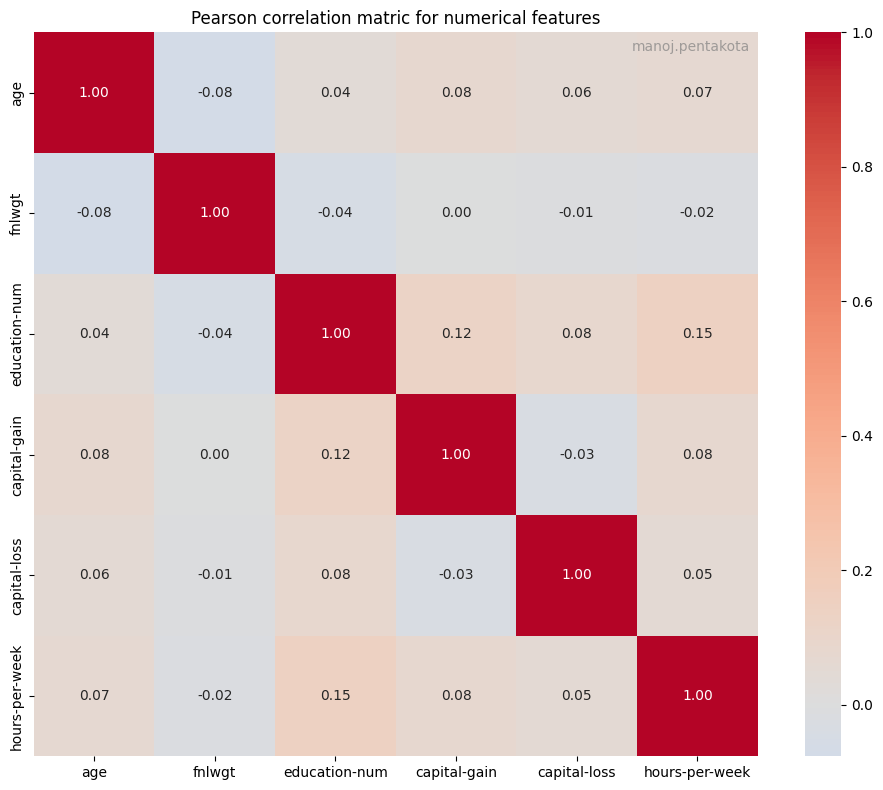

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Pearson correlation matric for numerical features")
plt.text(0.99,0.99,"manoj.pentakota",
         ha='right',va='top',
         transform=plt.gca().transAxes,
         fontsize=10,color='gray',alpha=0.7)
plt.tight_layout()
plt.show()

from the above pearson correlation matrix for the numerical features. no pair of features has shown particularly strong correlation but ffnlwgt feature had a particularly weak correation comparitive to other numerical features.

In [ ]:
redundant_features = ["fnlwgt"]
data=data.drop(columns=redundant_features)

print("remaining no of features:", data.shape[1])

remaining no of features: 14


In [ ]:
# train val test split

from sklearn.model_selection import train_test_split

x=data.drop(columns=["income"])
y=data["income"]

x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=seed,stratify=y)

adult_test = pd.read_csv(
    "/content/adult.test",
    header=None,
    names=columns,
    skipinitialspace=True,
    na_values="?",
    skiprows=1
)

# remove the previous redundant feature
adult_test=adult_test.drop(columns=redundant_features)

#remove the "." for the test set income labels
adult_test["income"]=adult_test["income"].str.replace(".","")

x_test=adult_test.drop(columns=["income"])
y_test=adult_test["income"]

print(f"training: {x_train.shape[0]}")
print(f"validation: {x_val.shape[0]}")
print(f"test: {x_test.shape[0]}")

training: 26048
validation: 6513
test: 16281


In [ ]:
def class_distribution(y, split_name):
  counts= y.value_counts()
  proportions = y.value_counts(normalize=True)*100

  return pd.DataFrame({
      "split": split_name,
      "class": counts.index,
      "count": counts.values,
      "proportion": proportions.values
  })

split_distribution = pd.concat([
    class_distribution(y_train, "train"),
    class_distribution(y_val, "validation"),
    class_distribution(y_test, "test")
], ignore_index=True)

display(split_distribution)

,split,class,count,proportion
0,train,<=50K,19775,75.917537
1,train,>50K,6273,24.082463
2,validation,<=50K,4945,75.925073
3,validation,>50K,1568,24.074927
4,test,<=50K,12435,76.377372
5,test,>50K,3846,23.622628


In [ ]:
"""
fill the missing values
for numerical features -> median
for categorical features -> mode

for numerical features median is choosen as modian is less sensitive to outliers
and for categorical mode represents the most frequently appeared label
"""
if "fnlwgt" in numerical_features:
  numerical_features.remove("fnlwgt")
numerical_imputation_values = {feature: x_train[feature].median() for feature in numerical_features}
categorical_imputation_values = {feature: x_train[feature].mode()[0] for feature in categorical_features}

for feature in numerical_features:
  x_train[feature] = x_train[feature].fillna(numerical_imputation_values[feature])
  x_val[feature] = x_val[feature].fillna(numerical_imputation_values[feature])
  x_test[feature] = x_test[feature].fillna(numerical_imputation_values[feature])

for feature in categorical_features:
  x_train[feature] = x_train[feature].fillna(categorical_imputation_values[feature])
  x_val[feature] = x_val[feature].fillna(categorical_imputation_values[feature])
  x_test[feature] = x_test[feature].fillna(categorical_imputation_values[feature])


print("training missing values")
display(x_train.isna().sum().sum())

print("\nvalidation missing values")
display(x_val.isna().sum().sum())

print("\ntest missing values")
display(x_test.isna().sum().sum())

training missing values


np.int64(0)


validation missing values


np.int64(0)


test missing values


np.int64(0)

In [ ]:
#categorical encoding

category_mapping={}
for feature in categorical_features:
  category_mapping[feature]=sorted(x_train[feature].unique())

for feature, categories in category_mapping.items():
  print(f"{feature}:")
  print(categories)
  print()

workclass:
['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']

education:
['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college']

marital-status:
['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']

occupation:
['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']

relationship:
['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']

race:
['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']

sex:
['Female', 'Male']

native-country:
['Cambodia', 'Canada', 'China', 'Columbia', 'Cuba', 'Domi

In [ ]:
def one_hot_encode(
    df, numerical_features, categorical_features, category_mapping):
  encoded_df = df[numerical_features].copy()
  for feature in categorical_features:
    categories = category_mapping[feature]
    for category in categories:
      column_name = f"{feature}_{category}"
      encoded_df[column_name] = (df[feature]==category).astype(int)
  return encoded_df

In [ ]:
x_train_encoded = one_hot_encode(x_train,numerical_features,categorical_features,category_mapping)
x_val_encoded = one_hot_encode(x_val,numerical_features,categorical_features,category_mapping)
x_test_encoded = one_hot_encode(x_test,numerical_features,categorical_features,category_mapping)

print(f"training: {x_train_encoded.shape}")
print(f"validation: {x_val_encoded.shape}")
print(f"test: {x_test_encoded.shape}")

print(f"final no of features after preprocessing: {x_train_encoded.shape[1]}")

training: (26048, 103)
validation: (6513, 103)
test: (16281, 103)
final no of features after preprocessing: 103


In [98]:
import numpy as np


def gini_impurity(y):
  if len(y) == 0:
    return 0.0

  _, counts = np.unique(y, return_counts=True)
  probabilities = counts/len(y)

  return 1.0 - np.sum(probabilities**2)

def entropy(y):
  if len(y) == 0:
    return 0.0

  _, counts = np.unique(y, return_counts=True)
  probabilities = counts/len(y)
  probabilities = probabilities[probabilities > 0]

  return -np.sum(probabilities*np.log2(probabilities))

def information_gain(y_parent, y_left, y_right):
  n = len(y_parent)
  n_left = len(y_left)
  n_right = len(y_right)

  if n == 0 or n_left == 0 or n_right == 0:
    return 0.0

  parent_entropy = entropy(y_parent)
  weighted_children = (n_left/n)*entropy(y_left) + (n_right/n)*entropy(y_right)

  return parent_entropy - weighted_children


class TreeNode:
  def __init__(self, feature_index=None, threshold=None, left=None, right=None, prediction=None, class_counts=None, proba=None):
    self.feature_index = feature_index
    self.threshold = threshold

    self.left = left
    self.right = right

    self.prediction = prediction # Non-None value of prediction means this is a leaf.

    self.class_counts = class_counts

    self.proba = proba # cached class-probability vector (leaf only), ordered like tree.classes_

  def is_leaf(self):
    return self.prediction is not None

class DecisionTree:
  def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1, criterion="gini", max_features=None, random_state=None):

    if criterion not in ("gini", "entropy"):
      raise ValueError("criterion must be 'gini' or 'entropy'")

    self.max_depth = max_depth
    self.min_samples_split = min_samples_split
    self.min_samples_leaf = min_samples_leaf
    self.criterion = criterion
    self.max_features = max_features
    self.random_state = random_state

    self.root = None

    self.n_features_ = None
    self.n_classes_ = None
    self.classes_ = None

    self.n_leaves_ = 0
    self.max_depth_ = 0

    self.feature_importances_ = None

    self.rng = np.random.default_rng(random_state)


  def fit(self, X, y):
    x = np.asarray(X, dtype=np.float64)
    y = np.asarray(y)

    self.n_features_ = x.shape[1]
    # Encode labels as integers ONCE; whole tree is built on integer labels.
    self.classes_, y_idx = np.unique(y, return_inverse=True)
    y_idx = y_idx.ravel()
    self.n_classes_ = len(self.classes_)

    self.n_leaves_ = 0
    self.max_depth_ = 0

    self._feature_importance_raw = np.zeros(self.n_features_,dtype=float)
    self.root = self._build_tree(x, y_idx, depth=0)

    #normalize the feature importance
    total_importance = np.sum(self._feature_importance_raw)
    if total_importance > 0:
      self.feature_importances_ = self._feature_importance_raw/total_importance
    else:
      self.feature_importances_ = np.zeros(self.n_features_, dtype=float)

    return self

  # ---------------------------------------------------------
  # Vectorized traversal: pushes whole groups of rows down the tree
  # instead of walking one row at a time in Python.
  # ---------------------------------------------------------
  def _traverse(self, x, want_proba):
    n = x.shape[0]
    if want_proba:
      out = np.zeros((n, self.n_classes_), dtype=float)
    else:
      out = np.empty(n, dtype=self.classes_.dtype)

    stack = [(self.root, np.arange(n))]
    while stack:
      node, idx = stack.pop()
      if len(idx) == 0:
        continue
      if node.is_leaf():
        if want_proba:
          out[idx] = node.proba
        else:
          out[idx] = node.prediction
      else:
        go_left = x[idx, node.feature_index] <= node.threshold
        stack.append((node.left, idx[go_left]))
        stack.append((node.right, idx[~go_left]))
    return out

  def predict(self, X):
    x = np.asarray(X, dtype=np.float64)
    return self._traverse(x, want_proba=False)

  def predict_proba(self, X):
    x = np.asarray(X, dtype=np.float64)
    return self._traverse(x, want_proba=True)

    # =========================================================
    # TREE CONSTRUCTION
    # =========================================================

  def _build_tree(self, X, y, depth):
    # y here is an array of integer class indices
    self.max_depth_ = max(self.max_depth_,depth)
    # 1. Check stopping conditions
    if self._should_stop(y,depth):
      return self._make_leaf(y)
    # 2. Select candidate features
    feature_indices = self._select_features(self.n_features_)
    # 3. Find best split
    best_feature,best_threshold,best_gain=self._find_best_split_encoded(X,y,feature_indices)
    if best_feature is None:
      return self._make_leaf(y)

    #split the observations
    left_mask = X[:,best_feature]<=best_threshold
    right_mask = ~left_mask
    n_left = int(left_mask.sum())
    n_right = len(y) - n_left

    if n_left<self.min_samples_leaf or n_right<self.min_samples_leaf:
      return self._make_leaf(y)

    x_left = X[left_mask]
    x_right = X[right_mask]
    y_left = y[left_mask]
    y_right = y[right_mask]

    # 4. Record impurity reduction (best_gain already == parent - weighted children)
    n = len(y)
    self._feature_importance_raw[best_feature] += n*best_gain
    # 5. Recursively construct children
    left_child = self._build_tree(x_left,y_left,depth+1)
    right_child = self._build_tree(x_right,y_right,depth+1)

    return TreeNode(feature_index=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    # =========================================================
    # STOPPING CONDITIONS
    # =========================================================

  def _should_stop(self, y, depth):
    n = len(y)
    if n==0:
      return True
    if (self.max_depth is not None and depth>=self.max_depth):
      return True
    if n<self.min_samples_split:
      return True
    if n<2*self.min_samples_leaf:
      return True
    # pure node? (cheap check on integer labels)
    if y.min() == y.max():
      return True
    return False

    # =========================================================
    # LEAF
    # =========================================================

  def _make_leaf(self, y):
    counts = np.bincount(y, minlength=self.n_classes_)
    class_counts = {self.classes_[i]: int(c) for i, c in enumerate(counts) if c > 0}
    prediction = self.classes_[np.argmax(counts)]
    total = counts.sum()
    proba = counts / total if total > 0 else np.zeros(self.n_classes_, dtype=float)
    self.n_leaves_ += 1
    return TreeNode(prediction=prediction, class_counts=class_counts, proba=proba.astype(float))
    # =========================================================
    # IMPURITY
    # =========================================================

  def _impurity_from_counts(self, counts):
    # counts: (..., k) array of class counts. Returns impurity along last axis.
    n = counts.sum(axis=-1, keepdims=True)
    p = counts / np.maximum(n, 1)
    if self.criterion == "gini":
      return 1.0 - np.sum(p ** 2, axis=-1)
    with np.errstate(divide="ignore", invalid="ignore"):
      plogp = np.where(p > 0, p * np.log2(p), 0.0)
    return -np.sum(plogp, axis=-1)

  def _encode_labels(self, y):
    # Converts raw labels to integer class indices using self.classes_
    # (sets classes_ / n_classes_ if they have not been set yet).
    y = np.asarray(y)
    if self.classes_ is None:
      self.classes_ = np.unique(y)
    self.n_classes_ = len(self.classes_)
    return np.searchsorted(self.classes_, y)

  def _impurity(self, y):
    return self._impurity_encoded(self._encode_labels(y))

  def _find_best_split(self, X, y, feature_indices):
    # Accepts raw labels (same as the original implementation).
    X = np.asarray(X, dtype=np.float64)
    return self._find_best_split_encoded(X, self._encode_labels(y), feature_indices)

  def _impurity_encoded(self, y):
    if len(y) == 0:
      return 0.0
    counts = np.bincount(y, minlength=self.n_classes_).astype(np.float64)
    return float(self._impurity_from_counts(counts))

    # =========================================================
    # FEATURE SELECTION
    # =========================================================

  def _select_features(self, n_features):
    if self.max_features is None:
      return np.arange(n_features)
    if isinstance(self.max_features,(int,np.integer)):
      m = int(self.max_features)
    elif isinstance(self.max_features,(float,np.floating)):
      m = int(self.max_features*n_features)
    elif isinstance(self.max_features,str):
      if self.max_features == "sqrt":
        m=int(np.sqrt(n_features))
      elif self.max_features == "log2":
        m = int(np.log2(n_features))
      else:
        raise ValueError("unsupported max_features value")
    else:
      raise ValueError("invalid max_features")

    m = max(1,m)
    m = min(n_features,m)

    return self.rng.choice(n_features,size=m,replace=False)

    # =========================================================
    # SPLIT  (fully vectorized per feature)
    # =========================================================

  def _find_best_split_encoded(self, X, y, feature_indices):
    # y must be integer class indices (0..n_classes_-1)
    n = len(y)
    if n == 0:
      return None, None, 0.0

    k = self.n_classes_
    msl = self.min_samples_leaf

    total_counts = np.bincount(y, minlength=k).astype(np.float64)
    parent_impurity = float(self._impurity_from_counts(total_counts))

    # Per-split sizes are identical for every feature, so compute once per node.
    n_left = np.arange(1, n, dtype=np.float64)       # (n-1,)
    n_right = n - n_left
    size_ok = (n_left >= msl) & (n_right >= msl)
    if not size_ok.any():
      return None, None, 0.0
    w_left = n_left / n
    w_right = n_right / n

    class_ids = np.arange(k)

    best_feature = None
    best_threshold = None
    best_gain = -np.inf

    for feature_index in feature_indices:
      col = X[:, feature_index]
      order = np.argsort(col, kind="stable")
      vals = col[order]
      if vals[0] == vals[-1]:
        continue

      valid = size_ok & (vals[:-1] != vals[1:])
      if not valid.any():
        continue

      # cumulative class counts on the left for every possible threshold
      onehot = (y[order][:, None] == class_ids)                      # (n, k)
      left = np.cumsum(onehot, axis=0, dtype=np.float64)[:-1]        # (n-1, k)
      right = total_counts - left

      child = (w_left * self._impurity_from_counts(left)
               + w_right * self._impurity_from_counts(right))
      gain = np.where(valid, parent_impurity - child, -np.inf)

      i = int(np.argmax(gain))
      if gain[i] > best_gain:
        best_gain = float(gain[i])
        best_feature = feature_index
        best_threshold = (vals[i] + vals[i + 1]) / 2.0

    if best_feature is None:
      return None, None, 0.0

    return best_feature, best_threshold, best_gain


class RandomForest:
  def __init__(self, n_estimators, max_features, max_depth=None, min_samples_split=2, min_samples_leaf=1, criterion="gini", bootstrap=True, random_state=None):
    self.n_estimators = n_estimators
    self.max_depth = max_depth
    self.max_features = max_features
    self.min_samples_split = min_samples_split
    self.min_samples_leaf = min_samples_leaf
    self.criterion = criterion
    self.bootstrap = bootstrap
    self.random_state = random_state

    self.trees = []
    self.oob_indices = []

    self.classes_ = None
    self.n_classes_ = None
    self.n_features_ = None

    self.oob_predictions_ = None
    self.oob_score_ = None

    self.feature_importances_ = None

    self.rng = np.random.default_rng(random_state)

  def fit(self, X, y):
    x = np.asarray(X, dtype=np.float64)
    y = np.asarray(y)
    if x.ndim!=2:
      raise ValueError("X must be 2D")
    if len(x)!=len(y):
      raise ValueError("X and y must have the same length")

    self.n_features_ = x.shape[1]
    self.classes_ = np.unique(y)
    self.n_classes_ = len(self.classes_)
    self.trees = []
    self.oob_indices = []

    n_samples = len(x)
    for _ in range(self.n_estimators):
      if self.bootstrap:
        sample_indices=self.rng.choice(n_samples,size=n_samples,replace=True)
        selected=np.zeros(n_samples,dtype=bool)
        selected[sample_indices]=True
        oob_indices=np.where(~selected)[0]
      else:
        sample_indices=np.arange(n_samples)
        oob_indices=np.array([],dtype=int)
      x_bootstrap = x[sample_indices]
      y_bootstrap = y[sample_indices]
      tree_seed=int(self.rng.integers(0,2**32-1))
      tree = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split, min_samples_leaf=self.min_samples_leaf, criterion=self.criterion, max_features=self.max_features, random_state=tree_seed)
      tree.fit(x_bootstrap,y_bootstrap)
      self.trees.append(tree)
      self.oob_indices.append(oob_indices)

    if self.bootstrap:
      self._compute_oob_predictions(x,y)
      self._aggregate_feature_importance()
    return self

  def _vote_matrix(self, x):
    # (n_samples, n_classes) vote counts, fully vectorized
    n = x.shape[0]
    votes = np.zeros((n, self.n_classes_), dtype=np.int64)
    rows = np.arange(n)
    for tree in self.trees:
      pred_idx = np.searchsorted(self.classes_, tree.predict(x))
      votes[rows, pred_idx] += 1
    return votes

  def predict(self, X):
    x=np.asarray(X, dtype=np.float64)
    votes = self._vote_matrix(x)
    return self.classes_[np.argmax(votes, axis=1)]

  def predict_proba(self, X):
    x=np.asarray(X, dtype=np.float64)
    total = np.zeros((x.shape[0], self.n_classes_), dtype=float)
    for tree in self.trees:
      p = tree.predict_proba(x)
      # align columns in case a bootstrap sample missed a class
      cols = np.searchsorted(self.classes_, tree.classes_)
      total[:, cols] += p
    return total / len(self.trees)

    # =========================================================
    # OOB
    # =========================================================

  def _compute_oob_predictions(self, X, y):
    n_samples = len(X)
    votes = np.zeros((n_samples, self.n_classes_), dtype=np.int64)
    for tree, oob_indices in zip(self.trees,self.oob_indices):
      if len(oob_indices)==0:
        continue
      pred_idx = np.searchsorted(self.classes_, tree.predict(X[oob_indices]))
      votes[oob_indices, pred_idx] += 1

    tree_counts = votes.sum(axis=1)
    valid_mask = tree_counts > 0

    oob_predictions = np.empty(n_samples,dtype=object)
    oob_predictions[:]=None
    if np.any(valid_mask):
      best = self.classes_[np.argmax(votes[valid_mask], axis=1)]
      oob_predictions[valid_mask] = best
      self.oob_score_ = np.mean(best == y[valid_mask])
    else:
      self.oob_score_ = np.nan

    self.oob_predictions_ = oob_predictions
    self.oob_valid_mask_ = valid_mask
    self.oob_tree_counts_ = tree_counts

    # =========================================================
    # FEATURE IMPORTANCE
    # =========================================================

  def _aggregate_feature_importance(self):
    if len(self.trees)==0:
      self.feature_importances_ = None
      return
    tree_importances = np.array([tree.feature_importances_ for tree in self.trees])
    mean_importance = np.mean(tree_importances,axis=0)
    total = np.sum(mean_importance)
    if total > 0:
      mean_importance/=total
    self.feature_importances_ = mean_importance

  def impurity_feature_importance(self):
    return self.feature_importances_

    # =========================================================
    # PERMUTATION IMPORTANCE
    # =========================================================

  def permutation_importance(self, X, y, n_repeats=5):
    """
    Compute permutation feature importance using validation accuracy.

    Importance of a feature =
        baseline_accuracy - accuracy_after_permuting_feature

    Returns:
        dict containing:
            baseline_accuracy
            importances
            std
    """

    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y)

    n_samples, n_features = X.shape

    # ---------------------------------------------------------
    # 1. Baseline accuracy
    # ---------------------------------------------------------
    baseline_predictions = self.predict(X)
    baseline_accuracy = np.mean(baseline_predictions == y)

    # ---------------------------------------------------------
    # 2. Storage
    # ---------------------------------------------------------
    importance_scores = np.zeros(
        (n_repeats, n_features),
        dtype=np.float64
    )

    # Reusable copy instead of creating a new copy for
    # every feature permutation
    X_permuted = X.copy()

    # ---------------------------------------------------------
    # 3. Permute each feature
    # ---------------------------------------------------------
    for repeat in range(n_repeats):

        for feature_index in range(n_features):

            # Save original feature column
            original_column = X[:, feature_index].copy()

            # Shuffle the column in-place
            self.rng.shuffle(X_permuted[:, feature_index])

            # Predict using the permuted data
            permuted_predictions = self.predict(X_permuted)

            # Accuracy after permutation
            permuted_accuracy = np.mean(
                permuted_predictions == y
            )

            # Importance = decrease in accuracy
            importance_scores[
                repeat,
                feature_index
            ] = baseline_accuracy - permuted_accuracy

            # Restore original column
            X_permuted[:, feature_index] = original_column

    # ---------------------------------------------------------
    # 4. Aggregate over repeats
    # ---------------------------------------------------------
    importances = np.mean(
        importance_scores,
        axis=0
    )

    std = np.std(
        importance_scores,
        axis=0
    )

    return {
        "baseline_accuracy": baseline_accuracy,
        "importances": importances,
        "std": std
    }

In [ ]:
x_demo=x_train_encoded.iloc[:100].to_numpy()
y_demo=y_train.iloc[:100].to_numpy()
tree_demo=DecisionTree(
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    criterion="gini",
    max_features=None,
    random_state=seed
)
tree_demo.classes_ = np.unique(y_demo)
feature_indices = np.arange(x_demo.shape[1])
best_feature,best_threshold,best_gain=tree_demo._find_best_split(x_demo,y_demo,feature_indices)
print(best_feature,best_threshold,best_gain)

2 6509.5 0.07568936170212781


In [ ]:
import time
#test for the above desicion tree implementation

xtr=x_train_encoded.to_numpy()
xv=x_val_encoded.to_numpy()
ytr=y_train.to_numpy()
yv=y_val.to_numpy()

baseline_tree = DecisionTree(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    criterion="gini",
    max_features=None,
    random_state=seed
)

start_time=time.time()
baseline_tree.fit(xtr,ytr)
baseline_train_time=time.time()-start_time
train_pred=baseline_tree.predict(xtr)
train_accuracy=np.mean(train_pred==ytr)
val_pred=baseline_tree.predict(xv)
val_accuracy=np.mean(val_pred==yv)
print(f"training accuracy : {train_accuracy:.4f}")
print(f"validation accuracy: {val_accuracy:.4f}")
print(f"number of leaves  : {baseline_tree.n_leaves_}")
print(f"actual max depth  : {baseline_tree.max_depth_}")
print(f"training time     : {baseline_train_time:.2f} seconds")

training accuracy : 0.9780
validation accuracy: 0.8168
number of leaves  : 4632
actual max depth  : 46
training time     : 13.90 seconds


In [ ]:
depth_values=[1,3,5,7,None]
depth_results=[]
for depth in depth_values:
  tree=DecisionTree(
      max_depth=depth,
      min_samples_split=2,
      min_samples_leaf=1,
      criterion="gini",
      max_features=None,
      random_state=seed)
  start_time=time.time()
  tree.fit(xtr,ytr)
  training_time=time.time()-start_time
  train_pred=tree.predict(xtr)
  train_accuracy=np.mean(train_pred==ytr)
  val_pred=tree.predict(xv)
  val_accuracy=np.mean(val_pred==yv)
  depth_results.append({
      "max_depth":"unrestricted" if depth is None else depth,
      "train_accuracy":train_accuracy,
      "val_accuracy":val_accuracy,
      "n_leaves":tree.n_leaves_,
      "actual_max_depth":tree.max_depth_,
      "training_time_sec":training_time
  })
depth_results_df=pd.DataFrame(depth_results)
depth_results_df

,max_depth,train_accuracy,val_accuracy,n_leaves,actual_max_depth,training_time_sec
0,1,0.759175,0.759251,2,1,0.465892
1,3,0.844287,0.842315,8,3,1.386591
2,5,0.853962,0.847996,29,5,2.248682
3,7,0.860911,0.852449,77,7,4.250674
4,unrestricted,0.977964,0.816828,4632,46,13.859357


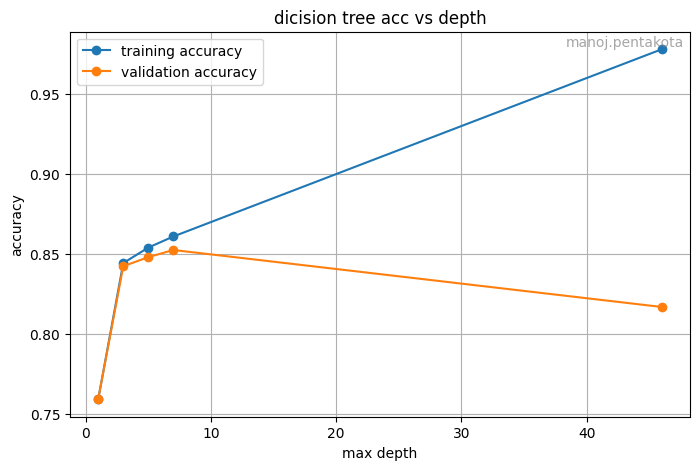

In [ ]:
plot_depths = [1,3,5,7,depth_results_df["actual_max_depth"].iloc[-1]]
plt.figure(figsize=(8,5))
plt.plot(
    plot_depths,
    depth_results_df["train_accuracy"],
    marker='o',
    label="training accuracy"
)
plt.plot(
    plot_depths,
    depth_results_df["val_accuracy"],
    marker='o',
    label="validation accuracy"
)
plt.xlabel("max depth")
plt.ylabel("accuracy")
plt.title(f"dicision tree acc vs depth")
plt.text(0.99,0.99,"manoj.pentakota",
         ha='right',va='top',
         transform=plt.gca().transAxes,
         fontsize=10,color='gray',alpha=0.7)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_depth_row = depth_results_df.loc[
    depth_results_df["val_accuracy"].idxmax()
]
best_depth = best_depth_row["max_depth"]
if best_depth == "unrestricted":
  best_depth=None
print("best depth based on validation accuracy:",
      "unrestricted" if best_depth is None else best_depth)

best depth based on validation accuracy: 7


In [ ]:
criterion_results=[]
for criterion in ["gini","entropy"]:
  tree=DecisionTree(
      max_depth=best_depth,
      min_samples_split=2,
      min_samples_leaf=1,
      criterion=criterion,
      max_features=None,
      random_state=seed)
  start_time=time.time()
  tree.fit(xtr,ytr)
  training_time=time.time()-start_time
  train_pred=tree.predict(xtr)
  train_accuracy=np.mean(train_pred==ytr)
  val_pred=tree.predict(xv)
  val_accuracy=np.mean(val_pred==yv)
  criterion_results.append({
      "criterion":criterion,
      "train_accuracy":train_accuracy,
      "val_accuracy":val_accuracy,
      "n_leaves":tree.n_leaves_,
      "actual_max_depth":tree.max_depth_,
      "training_time_sec":training_time
  })
criterion_results_df=pd.DataFrame(criterion_results)
criterion_results_df

,criterion,train_accuracy,val_accuracy,n_leaves,actual_max_depth,training_time_sec
0,gini,0.860911,0.852449,77,7,3.131450
1,entropy,0.858953,0.846768,76,7,4.990735


In [ ]:
# bootstrap sampling
N = len(xtr)
n_bootstrap_samples = 10
bootstrap_results=[]

for i in range(n_bootstrap_samples):
  rng = np.random.default_rng(seed+i)
  sample_indices=rng.choice(N,size=N,replace=True)
  unique_indices=np.unique(sample_indices)
  n_unique = len(unique_indices)
  n_not_selected = N-n_unique
  bootstrap_results.append({
      "bootstrap_sample":i+1,
      "unique_observations":n_unique,
      "not_selected":n_not_selected,
      "unique_fraction":n_unique/N,
      "not_selected_fraction":n_not_selected/N
  })
bootstrap_results_df = pd.DataFrame(bootstrap_results)
bootstrap_results_df

,bootstrap_sample,unique_observations,not_selected,unique_fraction,not_selected_fraction
0,1,16442,9606,0.631219,0.368781
1,2,16341,9707,0.627342,0.372658
2,3,16513,9535,0.633945,0.366055
3,4,16434,9614,0.630912,0.369088
4,5,16499,9549,0.633408,0.366592
5,6,16483,9565,0.632793,0.367207
6,7,16552,9496,0.635442,0.364558
7,8,16501,9547,0.633484,0.366516
8,9,16444,9604,0.631296,0.368704
9,10,16406,9642,0.629837,0.370163


In [ ]:
expected_unique_fraction = 1 - np.exp(-1)
mean_unique_fraction = bootstrap_results_df["unique_fraction"].mean()
mean_not_selected_fraction = bootstrap_results_df["not_selected_fraction"].mean()
print(f"expected unique fraction: {expected_unique_fraction:.4f}")
print(f"mean unique fraction: {mean_unique_fraction:.4f}")
print(f"mean not selected fraction: {mean_not_selected_fraction:.4f}")

expected unique fraction: 0.6321
mean unique fraction: 0.6320
mean not selected fraction: 0.3680


in botstrap sample of size N , observations are sampled with replacement. the probability that a particular observation is not selected is (1-1/N)^N which approaches e^-1 which is about 0.368. therefore the expected fraction of observations appearing at least once are 1-0.368 = 0.632. oue experimental result should be close to this value with some variation due to randomness

In [ ]:
p=xtr.shape[1]
bagging_tree_counts = [1,10,25,50,100]
bagging_results=[]

for B in bagging_tree_counts:
  bagging_model=RandomForest(
      n_estimators=B,
      max_features=p,
      max_depth=7,
      min_samples_split=2,
      min_samples_leaf=1,
      criterion="gini",
      bootstrap=True,
      random_state=seed
  )

  start_time=time.time()
  bagging_model.fit(xtr,ytr)
  training_time=time.time()-start_time
  val_pred=bagging_model.predict(xv)
  val_accuracy=np.mean(val_pred==yv)
  bagging_results.append({
      "n_trees":B,
      "validation_accuracy":val_accuracy,
      "validation_error":1-val_accuracy,
      "training_time_sec":training_time
  })
bagging_results_df=pd.DataFrame(bagging_results)
bagging_results_df

,n_trees,validation_accuracy,validation_error,training_time_sec
0,1,0.850453,0.149547,3.324604
1,10,0.852142,0.147858,39.520859
2,25,0.852449,0.147551,85.480792
3,50,0.853063,0.146937,171.699071
4,100,0.852756,0.147244,342.051151


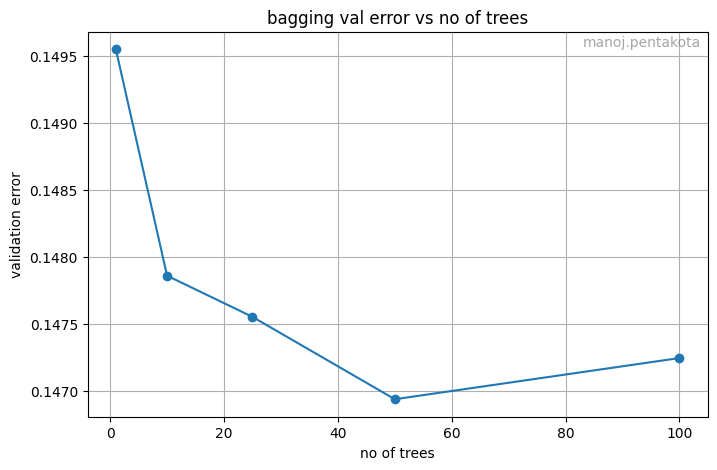

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    bagging_results_df["n_trees"],
    bagging_results_df["validation_error"],
    marker="o"
)
plt.xlabel("no of trees")
plt.ylabel("validation error")
plt.title("bagging val error vs no of trees")
plt.text(0.99,0.99,"manoj.pentakota",
         ha='right',va='top',
         transform=plt.gca().transAxes,
         fontsize=10,color='gray',alpha=0.7)
plt.grid(True)
plt.show()

In [ ]:
#Random forest

p=xtr.shape[1]
m_values=[
    1,
    max(1,int(np.sqrt(p))),
    max(1,p//2),
    p
]

print("no of features:",p)
print("candidate m values:",m_values)

no of features: 103
candidate m values: [1, 10, 51, 103]


In [ ]:
RF_COMPARISON_TREES=10
random_feature_results=[]
for m in m_values:
  rf_model=RandomForest(
      n_estimators=RF_COMPARISON_TREES,
      max_features=m,
      max_depth=7,
      min_samples_split=2,
      min_samples_leaf=1,
      criterion="gini",
      bootstrap=True,
      random_state=seed
  )
  start_time = time.time()
  rf_model.fit(xtr,ytr)
  training_time=time.time()-start_time
  train_pred=rf_model.predict(xtr)
  val_pred=rf_model.predict(xv)
  train_accuracy=np.mean(train_pred==ytr)
  val_accuracy=np.mean(val_pred==yv)
  oob_accuracy=rf_model.oob_score_
  random_feature_results.append({
      "m":m,
      "train_accuracy":train_accuracy,
      "val_accuracy":val_accuracy,
      "oob_accuracy":oob_accuracy,
      "training_time_sec":training_time
  })
random_feature_results_df=pd.DataFrame(random_feature_results)
random_feature_results_df

,m,train_accuracy,val_accuracy,oob_accuracy,training_time_sec
0,1,0.759175,0.759251,0.761006,1.516963
1,10,0.841178,0.834178,0.832390,4.943607
2,51,0.859529,0.850453,0.854557,17.305765
3,103,0.861064,0.852142,0.856263,33.950986


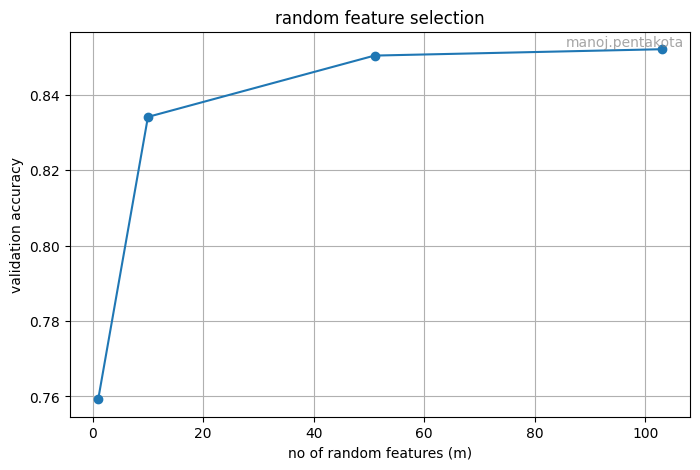

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    random_feature_results_df["m"],
    random_feature_results_df["val_accuracy"],
    marker="o"
)
plt.xlabel("no of random features (m)")
plt.ylabel("validation accuracy")
plt.title("random feature selection")
plt.text(0.99,0.99,"manoj.pentakota",
         ha='right',va='top',
         transform=plt.gca().transAxes,
         fontsize=10,color='gray',alpha=0.7)
plt.grid(True)
plt.show()

In [ ]:
rf_tree_counts=[1,10,50,100,250]
rf_tree_results=[]
for B in rf_tree_counts:
  rf_model=RandomForest(
      n_estimators=B,
      max_features=p,
      max_depth=7,
      min_samples_split=2,
      min_samples_leaf=1,
      criterion="gini",
      bootstrap=True,
      random_state=seed
  )
  start_time = time.time()
  rf_model.fit(xtr,ytr)
  training_time=time.time()-start_time
  train_pred=rf_model.predict(xtr)
  val_pred=rf_model.predict(xv)
  train_accuracy=np.mean(train_pred==ytr)
  val_accuracy=np.mean(val_pred==yv)
  rf_tree_results.append({
      "n_trees":B,
      "train_accuracy":train_accuracy,
      "val_accuracy":val_accuracy,
      "val_error":1-val_accuracy,
      "training_time_sec":training_time
  })
rf_tree_results_df=pd.DataFrame(rf_tree_results)
rf_tree_results_df

,n_trees,train_accuracy,val_accuracy,val_error,training_time_sec
0,1,0.859644,0.850453,0.149547,3.644043
1,10,0.861064,0.852142,0.147858,35.378049
2,50,0.861333,0.853063,0.146937,174.969780
3,100,0.861141,0.852756,0.147244,342.547712
4,250,0.861333,0.852756,0.147244,855.752557


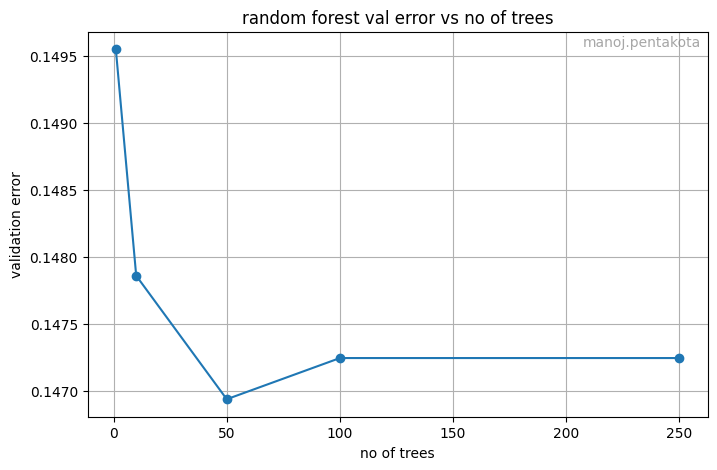

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    rf_tree_results_df["n_trees"],
    rf_tree_results_df["val_error"],
    marker="o"
)
plt.xlabel("no of trees")
plt.ylabel("validation error")
plt.title("random forest val error vs no of trees")
plt.text(0.99,0.99,"manoj.pentakota",
         ha='right',va='top',
         transform=plt.gca().transAxes,
         fontsize=10,color='gray',alpha=0.7)
plt.grid(True)
plt.show()

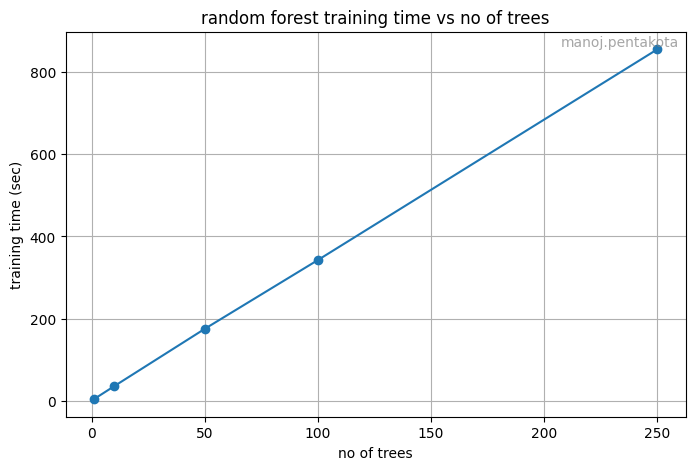

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    rf_tree_results_df["n_trees"],
    rf_tree_results_df["training_time_sec"],
    marker="o"
)
plt.xlabel("no of trees")
plt.ylabel("training time (sec)")
plt.title("random forest training time vs no of trees")
plt.text(0.99,0.99,"manoj.pentakota",
         ha='right',va='top',
         transform=plt.gca().transAxes,
         fontsize=10,color='gray',alpha=0.7)
plt.grid(True)
plt.show()

{review and rewrite by results} As the number of trees increases, the validation error generally decreases or stabilizes because averaging more decorrelated trees reduces variance. However, the computational cost increases approximately with the number of trees because additional trees must be trained. Beyond a certain number of trees, the improvement in validation performance becomes smaller relative to the additional training cost. Therefore, the preferred number of trees should balance validation performance and computational cost.

In [ ]:
best_tree_row = depth_results_df.loc[
    depth_results_df["val_accuracy"].idxmax()
]
best_rf_row = rf_tree_results_df.loc[
    rf_tree_results_df["val_accuracy"].idxmax()
]
print("best single tree")
print(best_tree_row)

print("\nbest random forest")
print(best_rf_row)

best single tree
max_depth                   7
train_accuracy       0.860911
val_accuracy         0.852449
n_leaves                   77
actual_max_depth            7
training_time_sec    4.250674
Name: 3, dtype: object

best random forest
n_trees               50.000000
train_accuracy         0.861333
val_accuracy           0.853063
val_error              0.146937
training_time_sec    174.969780
Name: 2, dtype: float64


In [ ]:
comparison_df=pd.DataFrame([
    {
        "model":"best decision tree",
        "validation accuracy": best_tree_row["val_accuracy"],
        "training time": best_tree_row["training_time_sec"],
        "leaves": best_tree_row["n_leaves"],
        "actual depth": best_tree_row["actual_max_depth"]
    },
    {
        "model":"best random forest",
        "validation accuracy": best_rf_row["val_accuracy"],
        "training time": best_rf_row["training_time_sec"],
        "leaves": "multiple trees",
        "actual depth": "multiple trees"
    }
])

comparison_df

,model,validation accuracy,training time,leaves,actual depth
0,best decision tree,0.852449,4.250674,77,7
1,best random forest,0.853063,174.969780,multiple trees,multiple trees


In [ ]:
# out of bag evals

best_rf = RandomForest(
    n_estimators=50,
    max_features=p,
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=1,
    criterion="gini",
    bootstrap=True,
    random_state=seed
)
start_time=time.time()
best_rf.fit(xtr,ytr)
oob_training_time = time.time()-start_time

print(f"oob accuracy: {best_rf.oob_score_:.4f}")
print(f"training time: {oob_training_time:.2f}")

oob accuracy: 0.8579
training time: 175.38


In [ ]:
n_samples = len(ytr)
n_trees = len(best_rf.trees)
oob_tree_counts = np.zeros(n_samples, dtype=int)
for tree_oob_indices in best_rf.oob_indices:
    oob_tree_counts[tree_oob_indices] += 1

print("Number of training observations:", n_samples)
print("Number of trees:", n_trees)

print("\nOOB tree count statistics")
print(f"Minimum : {oob_tree_counts.min()}")
print(f"Maximum : {oob_tree_counts.max()}")
print(f"Mean    : {oob_tree_counts.mean():.2f}")
print(f"Median  : {np.median(oob_tree_counts):.2f}")

Number of training observations: 26048
Number of trees: 50

OOB tree count statistics
Minimum : 7
Maximum : 34
Mean    : 18.40
Median  : 18.00


In [ ]:
oob_distribution = (
    pd.Series(oob_tree_counts)
    .value_counts()
    .sort_index()
    .reset_index()
)
oob_distribution.columns = [
    "number_of_oob_trees",
    "number_of_observations"
]
oob_distribution["proportion"] = (
    oob_distribution["number_of_observations"] / n_samples
)
oob_distribution

,number_of_oob_trees,number_of_observations,proportion
0,7,4,0.000154
1,8,22,0.000845
2,9,57,0.002188
3,10,129,0.004952
4,11,271,0.010404
5,12,481,0.018466
6,13,912,0.035012
7,14,1436,0.055129
8,15,1828,0.070178
9,16,2407,0.092406


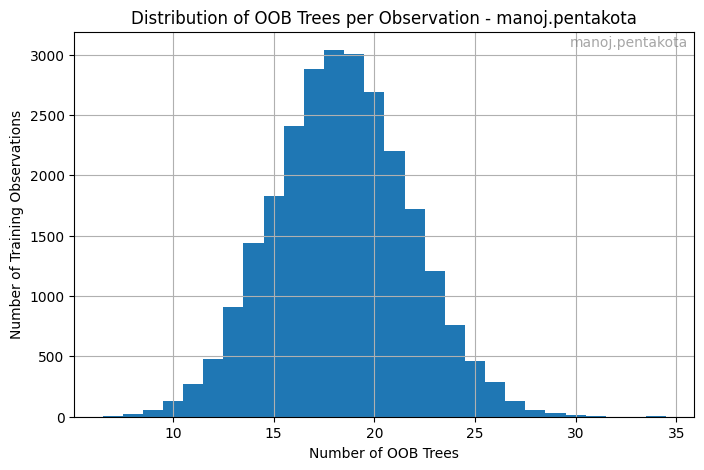

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(
    oob_tree_counts,
    bins=np.arange(
        oob_tree_counts.min(),
        oob_tree_counts.max() + 2
    ) - 0.5
)
plt.xlabel("Number of OOB Trees")
plt.ylabel("Number of Training Observations")
plt.title(f"Distribution of OOB Trees per Observation - {username}")
plt.text(0.99, 0.99, "manoj.pentakota",
         ha='right', va='top',
         transform=plt.gca().transAxes,
         fontsize=10, color='gray', alpha=0.7)
plt.grid(True)
plt.show()

In [ ]:
oob_accuracy = best_rf.oob_score_
oob_error = 1 - oob_accuracy

print(f"OOB accuracy: {oob_accuracy:.4f}")
print(f"OOB error   : {oob_error:.4f}")

OOB accuracy: 0.8579
OOB error   : 0.1421


In [ ]:
validation_predictions = best_rf.predict(xv)
validation_accuracy = np.mean(
    validation_predictions == yv
)
validation_error = 1 - validation_accuracy

print(f"Validation accuracy: {validation_accuracy:.4f}")
print(f"Validation error   : {validation_error:.4f}")

Validation accuracy: 0.8531
Validation error   : 0.1469


In [ ]:
oob_validation_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Error"
    ],
    "OOB": [
        oob_accuracy,
        oob_error
    ],
    "Validation": [
        validation_accuracy,
        validation_error
    ]
})

oob_validation_comparison

,Metric,OOB,Validation
0,Accuracy,0.857878,0.853063
1,Error,0.142122,0.146937


In [ ]:
# 1.6 hyperparam study
sqrt_p = max(1, int(np.sqrt(p)))

depth_values_16 = [2, 4, 6, 10, None]
depth_hyperparameter_results = []
for depth in depth_values_16:
    rf_model = RandomForest(
        n_estimators=10,
        max_features=sqrt_p,
        max_depth=depth,
        min_samples_split=2,
        min_samples_leaf=1,
        criterion="gini",
        bootstrap=True,
        random_state=seed
    )
    start_time = time.time()
    rf_model.fit(xtr, ytr)
    training_time = time.time() - start_time
    train_pred = rf_model.predict(xtr)
    val_pred = rf_model.predict(xv)
    train_accuracy = np.mean(train_pred == ytr)
    val_accuracy = np.mean(val_pred == yv)
    depth_hyperparameter_results.append({
        "max_depth": (
            "unrestricted" if depth is None else depth
        ),
        "train_accuracy": train_accuracy,
        "validation_accuracy": val_accuracy,
        "validation_error": 1 - val_accuracy,
        "oob_accuracy": rf_model.oob_score_,
        "training_time_sec": training_time
    })
depth_hyperparameter_df = pd.DataFrame(
    depth_hyperparameter_results
)
depth_hyperparameter_df

,max_depth,train_accuracy,validation_accuracy,validation_error,oob_accuracy,training_time_sec
0,2,0.760634,0.760633,0.239367,0.773020,2.287225
1,4,0.793113,0.792569,0.207431,0.804953,3.320020
2,6,0.834268,0.827269,0.172731,0.819175,4.007955
3,10,0.847282,0.838938,0.161062,0.837700,7.263194
4,unrestricted,0.885749,0.858744,0.141256,0.851263,14.268016


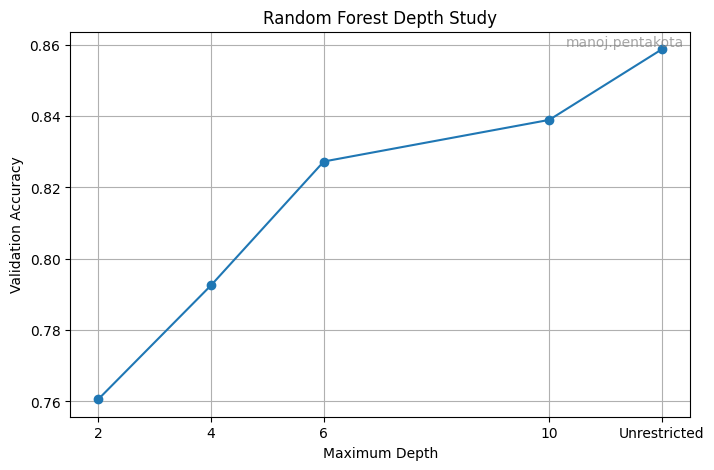

In [ ]:
plt.figure(figsize=(8, 5))
plot_x = [2, 4, 6, 10, 12]
plt.plot(
    plot_x,
    depth_hyperparameter_df["validation_accuracy"],
    marker="o"
)
plt.xticks(
    plot_x,
    ["2", "4", "6", "10", "Unrestricted"]
)
plt.xlabel("Maximum Depth")
plt.ylabel("Validation Accuracy")
plt.title("Random Forest Depth Study")
plt.text(0.99, 0.99, "manoj.pentakota",
         ha='right', va='top',
         transform=plt.gca().transAxes,
         fontsize=10, color='gray', alpha=0.7)
plt.grid(True)
plt.show()

In [ ]:
min_leaf_values = [1, 2, 5, 10, 25]
min_leaf_results = []
for min_leaf in min_leaf_values:
    rf_model = RandomForest(
        n_estimators=10,
        max_features=sqrt_p,
        max_depth=7,
        min_samples_split=2,
        min_samples_leaf=min_leaf,
        criterion="gini",
        bootstrap=True,
        random_state=seed
    )
    start_time = time.time()
    rf_model.fit(xtr, ytr)
    training_time = time.time() - start_time
    train_pred = rf_model.predict(xtr)
    val_pred = rf_model.predict(xv)
    train_accuracy = np.mean(train_pred == ytr)
    val_accuracy = np.mean(val_pred == yv)
    min_leaf_results.append({
        "min_samples_leaf": min_leaf,
        "train_accuracy": train_accuracy,
        "validation_accuracy": val_accuracy,
        "validation_error": 1 - val_accuracy,
        "oob_accuracy": rf_model.oob_score_,
        "training_time_sec": training_time
    })
min_leaf_results_df = pd.DataFrame(min_leaf_results)
min_leaf_results_df

,min_samples_leaf,train_accuracy,validation_accuracy,validation_error,oob_accuracy,training_time_sec
0,1,0.841178,0.834178,0.165822,0.832390,5.103236
1,2,0.832617,0.829418,0.170582,0.829445,4.293297
2,5,0.836149,0.829111,0.170889,0.826500,4.434866
3,10,0.827626,0.819899,0.180101,0.826112,4.152348
4,25,0.828317,0.822048,0.177952,0.827430,3.360844


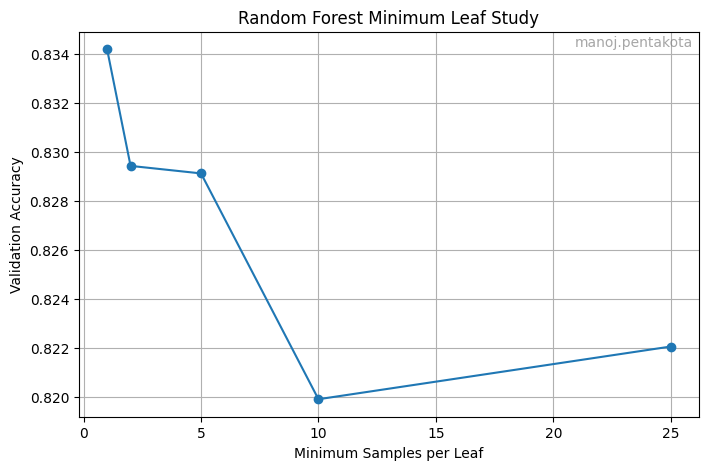

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    min_leaf_results_df["min_samples_leaf"],
    min_leaf_results_df["validation_accuracy"],
    marker="o"
)
plt.xlabel("Minimum Samples per Leaf")
plt.ylabel("Validation Accuracy")
plt.title("Random Forest Minimum Leaf Study")
plt.text(0.99, 0.99, "manoj.pentakota",
         ha='right', va='top',
         transform=plt.gca().transAxes,
         fontsize=10, color='gray', alpha=0.7)
plt.grid(True)
plt.show()

In [90]:
combined_configs = [
    {
        "n_estimators": 1,
        "max_depth": 7,
        "max_features": p,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 10,
        "max_depth": None,
        "max_features": sqrt_p,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 50,
        "max_depth": None,
        "max_features": p,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 10,
        "max_depth": 10,
        "max_features": sqrt_p,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 50,
        "max_depth": 7,
        "max_features": p,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 50,
        "max_depth": None,
        "max_features": sqrt_p,
        "min_samples_leaf": 1
    }
]

print("Number of configurations:", len(combined_configs))

Number of configurations: 6


In [91]:
combined_results = []
for config_id, config in enumerate(combined_configs, start=1):
    print(
        f"Running configuration {config_id}/"
        f"{len(combined_configs)}: {config}"
    )
    rf_model = RandomForest(
        n_estimators=config["n_estimators"],
        max_features=config["max_features"],
        max_depth=config["max_depth"],
        min_samples_split=2,
        min_samples_leaf=config["min_samples_leaf"],
        criterion="gini",
        bootstrap=True,
        random_state=seed
    )
    start_time = time.time()
    rf_model.fit(xtr, ytr)
    training_time = time.time() - start_time
    train_pred = rf_model.predict(xtr)
    val_pred = rf_model.predict(xv)
    train_accuracy = np.mean(train_pred == ytr)
    val_accuracy = np.mean(val_pred == yv)
    combined_results.append({
        "config_id": config_id,
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "max_features": config["max_features"],
        "min_samples_leaf": config["min_samples_leaf"],
        "train_accuracy": train_accuracy,
        "validation_accuracy": val_accuracy,
        "validation_error": 1 - val_accuracy,
        "oob_accuracy": rf_model.oob_score_,
        "training_time_sec": training_time
    })
combined_results_df = pd.DataFrame(combined_results)
combined_results_df

Running configuration 1/6: {'n_estimators': 1, 'max_depth': 7, 'max_features': 103, 'min_samples_leaf': 1}
Running configuration 2/6: {'n_estimators': 10, 'max_depth': None, 'max_features': 10, 'min_samples_leaf': 1}
Running configuration 3/6: {'n_estimators': 50, 'max_depth': None, 'max_features': 103, 'min_samples_leaf': 1}
Running configuration 4/6: {'n_estimators': 10, 'max_depth': 10, 'max_features': 10, 'min_samples_leaf': 1}
Running configuration 5/6: {'n_estimators': 50, 'max_depth': 7, 'max_features': 103, 'min_samples_leaf': 1}
Running configuration 6/6: {'n_estimators': 50, 'max_depth': None, 'max_features': 10, 'min_samples_leaf': 1}


,config_id,n_estimators,max_depth,max_features,min_samples_leaf,train_accuracy,validation_accuracy,validation_error,oob_accuracy,training_time_sec
0,1,1,7.0,103,1,0.859644,0.850453,0.149547,0.850614,3.622391
1,2,10,NaN,10,1,0.885749,0.858744,0.141256,0.851263,14.380254
2,3,50,NaN,103,1,0.977350,0.847229,0.152771,0.843328,577.472159
3,4,10,10.0,10,1,0.847282,0.838938,0.161062,0.837700,6.190663
4,5,50,7.0,103,1,0.861333,0.853063,0.146937,0.857878,185.150985
5,6,50,NaN,10,1,0.891508,0.864425,0.135575,0.859567,74.524107


In [92]:
best_config_row = combined_results_df.loc[
    combined_results_df["validation_accuracy"].idxmax()
]
print("Selected final configuration")
print("-" * 40)
print(
    best_config_row.to_string()
)

Selected final configuration
----------------------------------------
config_id               6.000000
n_estimators           50.000000
max_depth                    NaN
max_features           10.000000
min_samples_leaf        1.000000
train_accuracy          0.891508
validation_accuracy     0.864425
validation_error        0.135575
oob_accuracy            0.859567
training_time_sec      74.524107


In [93]:
final_n_estimators = int(
    best_config_row["n_estimators"]
)
final_max_depth = best_config_row["max_depth"]
if pd.isna(final_max_depth):
    final_max_depth = None
else:
    final_max_depth = int(final_max_depth)
final_max_features = int(
    best_config_row["max_features"]
)
final_min_samples_leaf = int(
    best_config_row["min_samples_leaf"]
)
print("Final parameters:")
print("n_estimators     :", final_n_estimators)
print("max_depth        :", final_max_depth)
print("max_features     :", final_max_features)
print("min_samples_leaf :", final_min_samples_leaf)

Final parameters:
n_estimators     : 50
max_depth        : None
max_features     : 10
min_samples_leaf : 1


In [94]:
# 1.7 Feature Importance

final_rf = RandomForest(
    n_estimators=final_n_estimators,
    max_features=final_max_features,
    max_depth=final_max_depth,
    min_samples_split=2,
    min_samples_leaf=final_min_samples_leaf,
    criterion="gini",
    bootstrap=True,
    random_state=seed
)
start_time = time.time()
final_rf.fit(xtr, ytr)
final_rf_training_time = time.time() - start_time
print(f"Training time: {final_rf_training_time:.2f} seconds")

Training time: 73.91 seconds


In [95]:
impurity_importance = final_rf.impurity_feature_importance()
impurity_importance_df = pd.DataFrame({
    "feature": x_train_encoded.columns,
    "impurity_importance": impurity_importance
})
impurity_importance_df = (
    impurity_importance_df
    .sort_values(
        "impurity_importance",
        ascending=False
    )
    .reset_index(drop=True)
)
impurity_importance_df.head(20)

,feature,impurity_importance
0,capital-gain,0.140417
1,marital-status_Married-civ-spouse,0.122673
2,education-num,0.101830
3,age,0.090093
4,hours-per-week,0.067260
5,relationship_Husband,0.063968
6,capital-loss,0.045527
7,occupation_Exec-managerial,0.029822
8,marital-status_Never-married,0.029715
9,education_Bachelors,0.017372


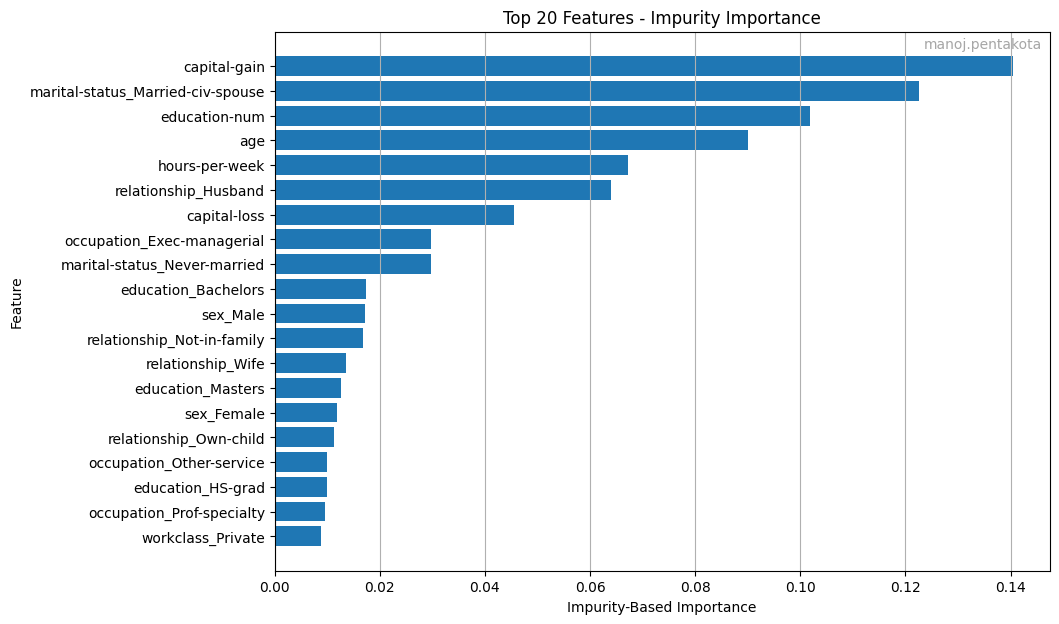

In [96]:
top_n = 20
top_impurity = impurity_importance_df.head(top_n)
plt.figure(figsize=(10, 7))
plt.barh(
    top_impurity["feature"][::-1],
    top_impurity["impurity_importance"][::-1]
)
plt.xlabel("Impurity-Based Importance")
plt.ylabel("Feature")
plt.title(
    f"Top {top_n} Features - Impurity Importance"
)
plt.text(0.99, 0.99, "manoj.pentakota",
         ha='right', va='top',
         transform=plt.gca().transAxes,
         fontsize=10, color='gray', alpha=0.7)
plt.grid(True, axis="x")
plt.show()

In [99]:
n_repeats = 5
permutation_result = final_rf.permutation_importance(
    xv,
    yv,
    n_repeats=n_repeats
)
permutation_importance_df = pd.DataFrame({
    "feature": x_train_encoded.columns,
    "permutation_importance": permutation_result["importances"],
    "std": permutation_result["std"]
})
permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        "permutation_importance",
        ascending=False
    )
    .reset_index(drop=True)
)
print("Baseline validation accuracy:",
      permutation_result["baseline_accuracy"])
permutation_importance_df.head(20)

Baseline validation accuracy: 0.8644249961615231


,feature,permutation_importance,std
0,capital-gain,0.038201,0.000470
1,marital-status_Married-civ-spouse,0.015907,0.001889
2,education-num,0.015600,0.001429
3,age,0.012621,0.001730
4,hours-per-week,0.010011,0.000809
5,capital-loss,0.008567,0.001034
6,relationship_Husband,0.006111,0.000797
7,occupation_Exec-managerial,0.004115,0.000948
8,relationship_Wife,0.003286,0.000230
9,occupation_Other-service,0.003224,0.000495


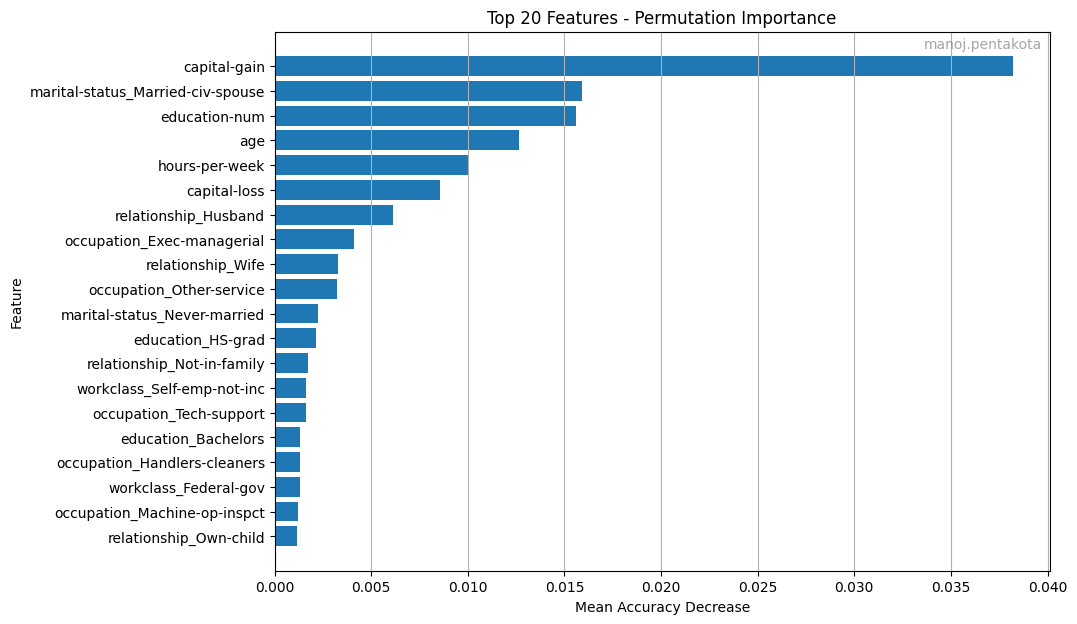

In [100]:
top_permutation = permutation_importance_df.head(top_n)
plt.figure(figsize=(10, 7))
plt.barh(
    top_permutation["feature"][::-1],
    top_permutation["permutation_importance"][::-1]
)
plt.xlabel("Mean Accuracy Decrease")
plt.ylabel("Feature")
plt.title(
    f"Top {top_n} Features - Permutation Importance"
)
plt.text(0.99, 0.99, "manoj.pentakota",
         ha='right', va='top',
         transform=plt.gca().transAxes,
         fontsize=10, color='gray', alpha=0.7)
plt.grid(True, axis="x")
plt.show()

In [101]:
importance_comparison = pd.merge(
    impurity_importance_df,
    permutation_importance_df,
    on="feature",
    how="outer"
)
importance_comparison["impurity_rank"] = (
    importance_comparison["impurity_importance"]
    .rank(
        ascending=False,
        method="min"
    )
)
importance_comparison["permutation_rank"] = (
    importance_comparison["permutation_importance"]
    .rank(
        ascending=False,
        method="min"
    )
)
importance_comparison = importance_comparison.sort_values(
    "impurity_rank"
)
importance_comparison.head(20)

,feature,impurity_importance,permutation_importance,std,impurity_rank,permutation_rank
1,capital-gain,0.140417,0.038201,0.000470,1.0,1.0
23,marital-status_Married-civ-spouse,0.122673,0.015907,0.001889,2.0,2.0
3,education-num,0.101830,0.015600,0.001429,3.0,3.0
0,age,0.090093,0.012621,0.001730,4.0,4.0
20,hours-per-week,0.067260,0.010011,0.000809,5.0,5.0
87,relationship_Husband,0.063968,0.006111,0.000797,6.0,7.0
2,capital-loss,0.045527,0.008567,0.001034,7.0,6.0
71,occupation_Exec-managerial,0.029822,0.004115,0.000948,8.0,8.0
25,marital-status_Never-married,0.029715,0.002242,0.000684,9.0,11.0
13,education_Bachelors,0.017372,0.001320,0.000430,10.0,16.0


In [102]:
top_impurity_features = set(
    impurity_importance_df.head(10)["feature"]
)
top_permutation_features = set(
    permutation_importance_df.head(10)["feature"]
)
common_features = (
    top_impurity_features &
    top_permutation_features
)
print("Top 10 impurity-based features:")
print(
    impurity_importance_df.head(10)["feature"].tolist()
)
print("\nTop 10 permutation features:")
print(
    permutation_importance_df.head(10)["feature"].tolist()
)
print("\nFeatures appearing in both top-10 lists:")
print(sorted(common_features))

Top 10 impurity-based features:
['capital-gain', 'marital-status_Married-civ-spouse', 'education-num', 'age', 'hours-per-week', 'relationship_Husband', 'capital-loss', 'occupation_Exec-managerial', 'marital-status_Never-married', 'education_Bachelors']

Top 10 permutation features:
['capital-gain', 'marital-status_Married-civ-spouse', 'education-num', 'age', 'hours-per-week', 'capital-loss', 'relationship_Husband', 'occupation_Exec-managerial', 'relationship_Wife', 'occupation_Other-service']

Features appearing in both top-10 lists:
['age', 'capital-gain', 'capital-loss', 'education-num', 'hours-per-week', 'marital-status_Married-civ-spouse', 'occupation_Exec-managerial', 'relationship_Husband']


The impurity-based importance measures how much each feature contributes to reducing node impurity across the trees. Features that frequently produce large impurity reductions receive higher importance.
Permutation importance instead measures the decrease in validation performance when the values of a feature are randomly permuted. Therefore, it reflects the feature's contribution to predictive performance on unseen data.
The two rankings are not necessarily identical. Differences can occur because impurity-based importance can favor features that provide many opportunities for splits, while permutation importance evaluates the effect of disrupting a feature's information on model predictions. Correlated or redundant features can also distribute predictive information across multiple variables, causing their rankings to differ.
Features appearing near the top under both methods can be considered consistently important for the model.

In [103]:
# final eval

final_model = RandomForest(
    n_estimators=final_n_estimators,
    max_features=final_max_features,
    max_depth=final_max_depth,
    min_samples_split=2,
    min_samples_leaf=final_min_samples_leaf,
    criterion="gini",
    bootstrap=True,
    random_state=seed
)
start_time = time.time()
final_model.fit(xtr, ytr)
final_training_time = time.time() - start_time
print("Final Random Forest")
print(f"Number of trees      : {final_n_estimators}")
print(f"Maximum depth        : {final_max_depth}")
print(f"Maximum features     : {final_max_features}")
print(f"Minimum leaf samples : {final_min_samples_leaf}")
print(f"Training time        : {final_training_time:.2f} seconds")

Final Random Forest
Number of trees      : 50
Maximum depth        : None
Maximum features     : 10
Minimum leaf samples : 1
Training time        : 74.17 seconds


In [104]:
xtest = x_test_encoded.to_numpy()
ytest = y_test.to_numpy()
test_predictions = final_model.predict(xtest)

In [105]:
test_accuracy = np.mean(
    test_predictions == ytest
)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.8633


In [106]:
positive_class = ">50K"
print("Positive class:", positive_class)
print("Classes:", np.unique(ytest))

Positive class: >50K
Classes: ['<=50K' '>50K']


In [107]:
actual_positive = (ytest == positive_class)
predicted_positive = (test_predictions == positive_class)
TP = np.sum(
    actual_positive & predicted_positive
)
TN = np.sum(
    ~actual_positive & ~predicted_positive
)
FP = np.sum(
    ~actual_positive & predicted_positive
)
FN = np.sum(
    actual_positive & ~predicted_positive
)
confusion_matrix = np.array([
    [TN, FP],
    [FN, TP]
])
print("Confusion Matrix")
print("-" * 40)
print(confusion_matrix)

print("\n                 Predicted")
print("                 <=50K    >50K")
print(
    f"Actual <=50K     {TN:6d}  {FP:6d}"
)
print(
    f"Actual >50K      {FN:6d}  {TP:6d}"
)

Confusion Matrix
----------------------------------------
[[11728   707]
 [ 1519  2327]]

                 Predicted
                 <=50K    >50K
Actual <=50K      11728     707
Actual >50K        1519    2327


In [108]:
precision = (
    TP / (TP + FP)
    if (TP + FP) > 0
    else 0.0
)
recall = (
    TP / (TP + FN)
    if (TP + FN) > 0
    else 0.0
)
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0.0
)
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.8633
Precision: 0.7670
Recall   : 0.6050
F1-score : 0.6765


In [109]:
final_test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Test Score": [
        test_accuracy,
        precision,
        recall,
        f1
    ]
})

final_test_results

,Metric,Test Score
0,Accuracy,0.863276
1,Precision,0.766974
2,Recall,0.605044
3,F1-score,0.676453


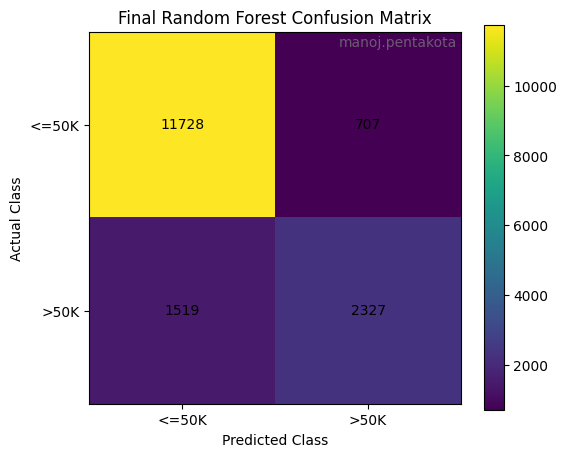

In [112]:
plt.figure(figsize=(6, 5))
plt.imshow(confusion_matrix)
plt.xticks(
    [0, 1],
    ["<=50K", ">50K"]
)
plt.yticks(
    [0, 1],
    ["<=50K", ">50K"]
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Final Random Forest Confusion Matrix")
plt.text(0.99, 0.99, "manoj.pentakota",
         ha='right', va='top',
         transform=plt.gca().transAxes,
         fontsize=10, color='gray', alpha=0.7)
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center"
        )
plt.colorbar()
plt.show()

In [113]:
# final model summary
print("FINAL MODEL SUMMARY")
print("=" * 50)
print(f"Number of trees      : {final_n_estimators}")
print(
    f"Maximum depth        : "
    f"{'unrestricted' if final_max_depth is None else final_max_depth}"
)
print(f"Maximum features     : {final_max_features}")
print(f"Minimum leaf samples : {final_min_samples_leaf}")
print(f"Criterion            : gini")
print(f"Bootstrap             : True")

print("\nFINAL TEST PERFORMANCE")
print("-" * 50)
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

FINAL MODEL SUMMARY
Number of trees      : 50
Maximum depth        : unrestricted
Maximum features     : 10
Minimum leaf samples : 1
Criterion            : gini
Bootstrap             : True

FINAL TEST PERFORMANCE
--------------------------------------------------
Accuracy  : 0.8633
Precision : 0.7670
Recall    : 0.6050
F1-score  : 0.6765
